In [ ]:
### import necessary libraries
from datetime import datetime
# import geopandas as gpd
# from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import math
import numpy as np
import os
from IPython.display import clear_output
import pandas as pd
import seaborn as sns
import scanpy as sc
import random
from adjustText import adjust_text
from sklearn.cluster import KMeans
# from sklearn.metrics import adjusted_rand_score
# from sklearn.neighbors import NearestNeighbors
# from sklearn.neighbors import KNeighborsClassifier
import warnings
from datetime import datetime

today = datetime.today().strftime('%Y-%m-%d')

pd.options.display.max_rows = 2000

import matplotlib.pyplot as plt

import matplotlib as mpl


# Ensure text remains editable in SVG

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

# warnings.filterwarnings("ignore") 
# sc.logging.print_header()
# sc.set_figure_params(facecolor="white", figsize=(4, 10))
# sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
# plt.rcParams["font.family"] = "Arial"
# sns.set_style("white")

start_time = datetime.now()

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color= ['#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

def print_with_elapsed_time(message):
    elapsed_time = datetime.now() - start_time
    elapsed_seconds = elapsed_time.total_seconds()
    print(f"[{elapsed_seconds:.2f} seconds] {message}")

In [20]:
df = pd.read_parquet('D:/Xenium/circa4-IGM-ZT01/transcripts.parquet', filters=[("qv",">=",20)])

In [21]:
df['id_bis'] = "ASSIGNED"

df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
df['id_bis'] = df['id_bis'].fillna('ASSIGNED')

In [22]:
ass_unass = df.groupby('id_bis')['feature_name'].value_counts(sort=False)

In [23]:
data = pd.DataFrame({'feature_name': df.feature_name.value_counts().index,'count' : df.feature_name.value_counts()})

In [24]:
data.sort_index(inplace=True)
data["UNASSIGNED"] =  ass_unass["UNASSIGNED"]
data["ASSIGNED"] =  ass_unass["ASSIGNED"]
data['ratio_un'] = data['UNASSIGNED'] / data['count']
data.head()

,feature_name,count,UNASSIGNED,ASSIGNED,ratio_un
feature_name,,,,,
A1cf,A1cf,139,19.0,120,0.136691
A2m,A2m,8518,2980.0,5538,0.349847
Aatf,Aatf,30636,7854.0,22782,0.256365
Abca1,Abca1,37685,15134.0,22551,0.401592
Abca13,Abca13,144,49.0,95,0.340278


In [25]:
data['type'] = data['feature_name'].apply(lambda x: x.split('_')[0])

In [26]:
data_control = data[data['type']=="NegControlProbe"]

In [27]:
percentile_threshold:float =99.5
threshold = np.percentile(data_control['count'].values,percentile_threshold)

In [28]:
data['logfoldovernoise'] = data['UNASSIGNED'].apply(lambda x: np.log(x / threshold))

In [29]:
data.sort_values(by='logfoldovernoise', ascending=False).head(10)

,feature_name,count,UNASSIGNED,ASSIGNED,ratio_un,type,logfoldovernoise
feature_name,,,,,,,
Camk2a,Camk2a,2862257,2223863.0,638394,0.776961,Camk2a,9.710000
Kif5a,Kif5a,2620767,2053347.0,567420,0.783491,Kif5a,9.630226
Map2,Map2,2020027,1407749.0,612278,0.696896,Map2,9.252746
Aldoc,Aldoc,1842512,1374368.0,468144,0.745921,Aldoc,9.228748
Ndrg2,Ndrg2,1754953,1345817.0,409136,0.766868,Ndrg2,9.207756
Ckb,Ckb,1862363,1090335.0,772028,0.585458,Ckb,8.997239
Kif5c,Kif5c,1291728,860337.0,431391,0.666036,Kif5c,8.760323
Atp1b2,Atp1b2,1469839,823427.0,646412,0.560216,Atp1b2,8.716474
Slc1a3,Slc1a3,1144761,757079.0,387682,0.661342,Slc1a3,8.632467


In [42]:
data.loc['Snap25']#['type'].unique()

feature_name          Snap25
count                1595938
UNASSIGNED          632910.0
ASSIGNED              963028
ratio_un            0.396576
type                  Snap25
logfoldovernoise    8.453327
color                  black
Name: Snap25, dtype: object

In [31]:
color = {"DeprecatedCodeword" : "blue",
         "NegControlCodeword" : 'green',
         "NegControlProbe" : "red",
         "UnassignedCodeword" : "purple"}
data['color'] = data['type'].map(color)
data['color'] = data['color'].fillna('black')

C:\Users\hcall\AppData\Local\Temp\ipykernel_5008\326485427.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x= data['logfoldovernoise'], y= data['ratio_un'], c=data['color'], cmap="hls", s = 2.5)


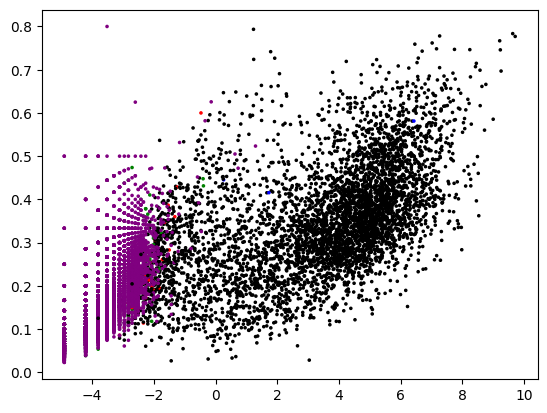

In [35]:
plt.scatter(x= data['logfoldovernoise'], y= data['ratio_un'], c=data['color'], cmap="hls", s = 2.5)

In [65]:
df = pd.read_parquet('D:/Xenium/3159-4/transcripts.parquet', filters=[("qv",">=",20), ('feature_name','=','Trem2')])
df.drop(['overlaps_nucleus','qv', 'codeword_index'],axis=1, inplace=True)
df['id_bis'] = df['cell_id'].map({'UNASSIGNED':"UNASSIGNED"})
df['id_bis'] = df['id_bis'].fillna('ASSIGNED')
df['color'] = df['id_bis'].map({'UNASSIGNED':'red','ASSIGNED':"black"})

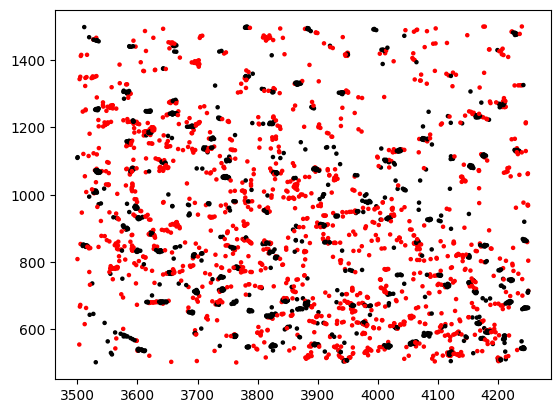

In [71]:
df_crop = df[(df['x_location'].between(3500,4250))&(df['y_location'].between(500,1500))]
# plt.figure(figsize = (10,6))
plt.scatter(x=df_crop['x_location'],y=df_crop['y_location'], color = df_crop['color'], s = 5)

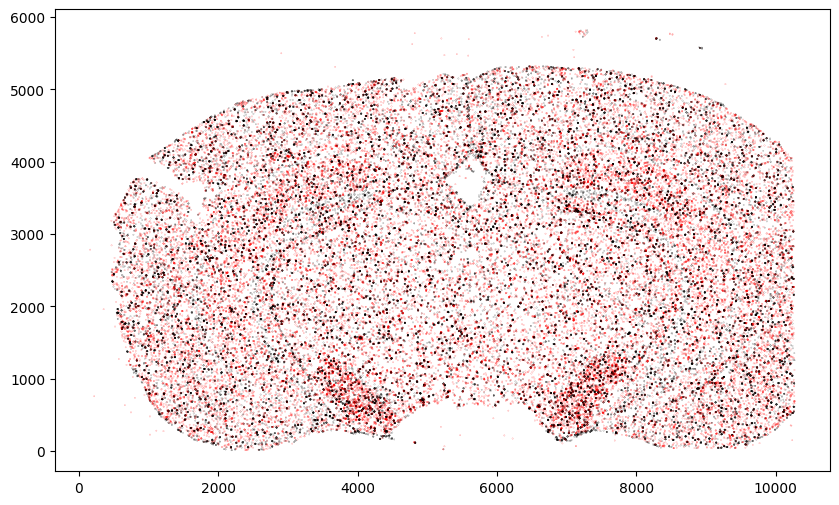

In [67]:
plt.figure(figsize = (10,6))
plt.scatter(x=df['x_location'],y=df['y_location'], color = df['color'], s = 0.01)